## Feature Engineering y definición de la etiqueta churn

Este notebook transforma los datos transaccionales en una tabla maestra (una fila por usuario)
con las variables predictoras y la etiqueta churn, usando una ventana de observación y una
ventana de etiqueta para evitar fuga de información (data leakage).

Realizaremos dos ventanas de tiempo, una para OBSERVAR (anterior a una fecha de corte que defibnimos en la celda 2), vemos el comportamiento del usuario y creamos las features, la otra ventana es para ETIQUETAR CHURN, es ver si el usuario abandono o no despues de la fecha de corte.

In [0]:
%python
DB = "workspace.apuestas_db"
DIAS_VENTANA_ETIQUETA = 30  # tamaño de la ventana posterior al corte para definir churn

Parametros de fecha

In [0]:

# Fecha de referencia: la fecha más reciente presente en los datos (no "hoy" del sistema,
# para que el proceso sea reproducible sin importar cuándo se corra este notebook)
fecha_referencia = spark.sql(f"""
    SELECT GREATEST(
        (SELECT MAX(fecha_apuesta) FROM {DB}.apuesta),
        (SELECT MAX(fecha_transaccion) FROM {DB}.transaccion)
    ) AS fecha_referencia
""").collect()[0].fecha_referencia

print(f"Fecha de referencia (última actividad en los datos): {fecha_referencia}")
print(f"Fecha de corte (referencia - {DIAS_VENTANA_ETIQUETA} días): se calculará en SQL")

Fecha de referencia (última actividad en los datos): 2026-07-19 22:22:43.060286
Fecha de corte (referencia - 30 días): se calculará en SQL


Construccion tabla maestra

In [0]:
spark.sql(f"""
CREATE OR REPLACE TABLE {DB}.tabla_maestra_churn AS

WITH p AS (
    SELECT
        TIMESTAMP('{fecha_referencia}') AS fecha_referencia,
        TIMESTAMP('{fecha_referencia}') - INTERVAL {DIAS_VENTANA_ETIQUETA} DAYS AS fecha_corte
),

-- 1.ventana de observación
-- Apuestas y transacciones ANTERIORES al corte 
apuestas_obs AS (
    SELECT a.* FROM {DB}.apuesta a CROSS JOIN p WHERE a.fecha_apuesta < p.fecha_corte
),
transacciones_obs AS (
    SELECT t.* FROM {DB}.transaccion t CROSS JOIN p WHERE t.fecha_transaccion < p.fecha_corte
),

-- 2.ventana de etiqueta
-- Usuarios con actividad POSTERIOR al corte 
actividad_label AS (
    SELECT id_usuario FROM {DB}.apuesta a CROSS JOIN p WHERE a.fecha_apuesta >= p.fecha_corte
    UNION
    SELECT id_usuario FROM {DB}.transaccion t CROSS JOIN p WHERE t.fecha_transaccion >= p.fecha_corte
),


-- 3: Métricas y características del comportamiento de apuestas 
features_apuestas AS (
    SELECT
        ao.id_usuario,
        -- fecha de la última apuesta realizada en la v.observación
        MAX(ao.fecha_apuesta) AS fecha_ultima_apuesta_obs,
        
        -- Volumen total de apuestas realizadas por el usuario
        COUNT(*) AS n_apuestas_total,
        
        -- Frecuencia de apuestas en los últimos 30 días previos a la fecha de corte
        SUM(CASE WHEN ao.fecha_apuesta >= p.fecha_corte - INTERVAL 30 DAYS THEN 1 ELSE 0 END) AS n_apuestas_ult30d,
        
        -- Frecuencia de apuestas realizadas antes de la ventana de los últimos 30 días
        SUM(CASE WHEN ao.fecha_apuesta <  p.fecha_corte - INTERVAL 30 DAYS THEN 1 ELSE 0 END) AS n_apuestas_previas,
        
        -- Promedio histórico del monto de las apuestas
        AVG(ao.monto) AS monto_promedio_apostado,
        
        -- Promedio del monto apostado en los últimos 30 días
        AVG(CASE WHEN ao.fecha_apuesta >= p.fecha_corte - INTERVAL 30 DAYS THEN ao.monto END) AS monto_promedio_ult30d,
        
        -- Cantidad de apuestas perdidas (estado 3)
        SUM(CASE WHEN ao.id_estado_apuesta = 3 THEN 1 ELSE 0 END) AS n_perdidas,
        
        -- Total de apuestas ya finalizadas/resueltas (ganadas 2 o perdidas 3)
        SUM(CASE WHEN ao.id_estado_apuesta IN (2,3) THEN 1 ELSE 0 END) AS n_resueltas
    FROM apuestas_obs ao 
    CROSS JOIN p -- Permite comparar las fechas contra el parámetro de fecha de corte 'p'
    GROUP BY ao.id_usuario
),

-- 4.Métricas del comportamiento de depósitos

features_depositos AS (
    SELECT
        tro.id_usuario,
        -- Fecha del último depósito registrado
        MAX(CASE WHEN tro.tipo_transaccion = 'deposito' THEN tro.fecha_transaccion END) AS fecha_ultimo_deposito_obs,
        
        -- Total de transacciones de tipo depósito
        COUNT(CASE WHEN tro.tipo_transaccion = 'deposito' THEN 1 END) AS n_depositos,
        
        -- Suma total del dinero depositado por el usuario
        SUM(CASE WHEN tro.tipo_transaccion = 'deposito' THEN tro.monto ELSE 0 END) AS monto_total_depositado
    FROM transacciones_obs tro
    GROUP BY tro.id_usuario
)

-- 5. Integración final de variables y generación del Target (churn)
  

SELECT
    u.id_usuario,
    u.saldo,
    -- Recencia de la cuenta: dias desde el registro del usuario hasta la fecha de corte
    DATEDIFF(p.fecha_corte, u.fecha_registro) AS antiguedad_dias,

    -- Recencia de actividad: dias sin apostar ni depositar desde la fecha de corte
    COALESCE(DATEDIFF(p.fecha_corte, fa.fecha_ultima_apuesta_obs), 999) AS dias_desde_ultima_apuesta,
    CASE WHEN fa.fecha_ultima_apuesta_obs IS NULL THEN 1 ELSE 0 END AS sin_apuestas_obs,

    COALESCE(DATEDIFF(p.fecha_corte, fd.fecha_ultimo_deposito_obs), 999) AS dias_desde_ultimo_deposito,
    CASE WHEN fd.fecha_ultimo_deposito_obs IS NULL THEN 1 ELSE 0 END AS sin_depositos_obs,

    -- Frecuencia de apuestas e indicador de cambio de comportamiento (Tendencia)
    COALESCE(fa.n_apuestas_total, 0)    AS n_apuestas_total,
    COALESCE(fa.n_apuestas_ult30d, 0)   AS n_apuestas_ult30d,
    COALESCE(fa.n_apuestas_previas, 0)  AS n_apuestas_previas,

    -- Variación del volumen de apuestas: Positivo indica aceleración, negativo desaceleración
    COALESCE(fa.n_apuestas_ult30d, 0) - COALESCE(fa.n_apuestas_previas, 0) AS tendencia_frecuencia,

    -- Montos promedio monetarios
    ROUND(COALESCE(fa.monto_promedio_apostado, 0), 2) AS monto_promedio_apostado,
    ROUND(COALESCE(fa.monto_promedio_ult30d, 0), 2)   AS monto_promedio_ult30d,

    CASE WHEN fa.n_resueltas IS NULL OR fa.n_resueltas = 0 THEN 1 ELSE 0 END AS sin_apuestas_resueltas,
    -- Rendimiento del usuario: Porcentaje de apuestas perdidas respecto al total resuelto
    COALESCE(ROUND(fa.n_perdidas / NULLIF(fa.n_resueltas,0), 4), 0.5) AS tasa_perdida,

    -- Métricas de monetización (deposito)
    COALESCE(fd.n_depositos, 0) AS n_depositos,
    ROUND(COALESCE(fd.monto_total_depositado, 0), 2) AS monto_total_depositado,

    -- Variable objetivo (Target/Label):
    CASE WHEN al.id_usuario IS NULL THEN 1 ELSE 0 END AS churn

FROM {DB}.usuario u
CROSS JOIN p
LEFT JOIN features_apuestas   fa ON u.id_usuario = fa.id_usuario
LEFT JOIN features_depositos  fd ON u.id_usuario = fd.id_usuario
LEFT JOIN actividad_label     al ON u.id_usuario = al.id_usuario  
""")

print("✔ tabla_maestra_churn creada")

✔ tabla_maestra_churn creada


validacion tabla maestra

In [0]:

df_maestra = spark.table(f"{DB}.tabla_maestra_churn")

print("Distribución de churn:")
df_maestra.groupBy("churn").count().show()

print("Conteo de nulos por columna clave:")
df_maestra.selectExpr(
    "SUM(CASE WHEN dias_desde_ultima_apuesta IS NULL THEN 1 ELSE 0 END) AS nulos_recencia_apuesta",
    "SUM(CASE WHEN tasa_perdida IS NULL THEN 1 ELSE 0 END) AS nulos_tasa_perdida"
).show()

display(df_maestra.limit(10))

Distribución de churn:
+-----+-----+
|churn|count|
+-----+-----+
|    0|  479|
|    1|  321|
+-----+-----+

Conteo de nulos por columna clave:
+----------------------+------------------+
|nulos_recencia_apuesta|nulos_tasa_perdida|
+----------------------+------------------+
|                     0|                 0|
+----------------------+------------------+



id_usuario,saldo,antiguedad_dias,dias_desde_ultima_apuesta,sin_apuestas_obs,dias_desde_ultimo_deposito,sin_depositos_obs,n_apuestas_total,n_apuestas_ult30d,n_apuestas_previas,tendencia_frecuencia,monto_promedio_apostado,monto_promedio_ult30d,sin_apuestas_resueltas,tasa_perdida,n_depositos,monto_total_depositado,churn
1601,37369.86,166,1,0,20,0,33,7,26,-19,2668.51,2042.66,0,0.7037,7,20420.30,0
1602,4011.28,223,134,0,9,0,2,0,2,-2,536.45,0.00,0,1.0,1,3348.22,1
1603,34798.97,39,4,0,126,0,24,9,15,-6,2469.63,2919.22,0,0.6316,4,10783.83,0
1604,16159.98,302,78,0,132,0,3,0,3,-3,573.82,0.00,0,1.0,1,982.72,1
1605,30357.06,238,2,0,3,0,14,4,10,-6,2068.96,3523.69,0,0.5,5,12273.76,0
1606,3882.47,80,72,0,999,1,4,0,4,-4,887.58,0.00,0,0.5,0,0.00,1
1607,35853.14,267,11,0,29,0,19,4,15,-11,2569.06,3030.93,0,0.75,4,13299.29,0
1608,15249.40,179,70,0,7,0,2,0,2,-2,1331.31,0.00,0,1.0,2,7157.74,1
1609,31088.26,290,120,0,999,1,3,0,3,-3,715.22,0.00,0,1.0,0,0.00,1
1610,36044.36,100,4,0,65,0,21,6,15,-9,2658.60,2697.04,0,0.8333,2,2854.10,0


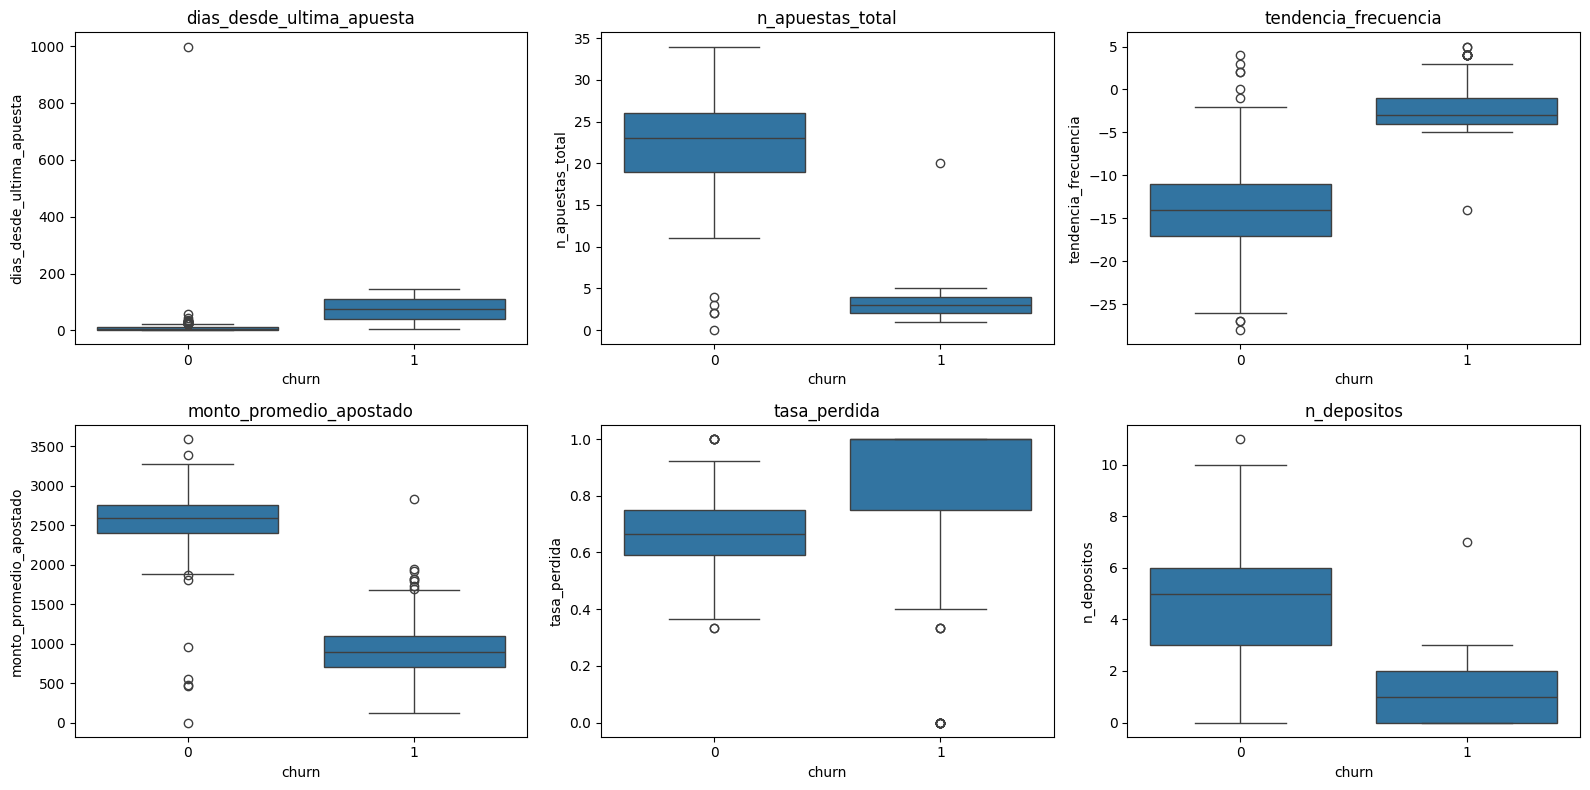

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

DB = "workspace.apuestas_db"
df_maestra_pd = spark.table(f"{DB}.tabla_maestra_churn").toPandas()

features_clave = [
    "dias_desde_ultima_apuesta", "n_apuestas_total", "tendencia_frecuencia",
    "monto_promedio_apostado", "tasa_perdida", "n_depositos"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flatten(), features_clave):
    sns.boxplot(data=df_maestra_pd, x="churn", y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

las cajas no se solapan y las medias son distintas para las variables definidas